In [2]:
!pip install --user matplotlib
!pip install --user pandas
!pip install --user scipy
!pip install --user tqdm

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo

In [1]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from tqdm.notebook import tqdm

In [2]:
data_dir = "/home/chanb/scratch/hint_rl_results/logs/chanb/openmath-dapo/"
match_prefix = "local_eval-hint_rl_163-epoch"
all_evals = sorted([
    filename for filename in os.listdir(data_dir)
    if (
        os.path.isdir(os.path.join(data_dir, filename))
        and filename.startswith(match_prefix)
        and len(os.listdir(os.path.join(data_dir, filename, "rollout/0"))) == 1853
    )
], key=lambda x: int(x.split("epoch")[1]))

In [3]:
all_evals

['local_eval-hint_rl_163-epoch0epochstep13globalstep13',
 'local_eval-hint_rl_163-epoch3epochstep13globalstep55',
 'local_eval-hint_rl_163-epoch4epochstep13globalstep69',
 'local_eval-hint_rl_163-epoch7epochstep13globalstep111',
 'local_eval-hint_rl_163-epoch8epochstep13globalstep125',
 'local_eval-hint_rl_163-epoch9epochstep13globalstep139',
 'local_eval-hint_rl_163-epoch10epochstep13globalstep153',
 'local_eval-hint_rl_163-epoch13epochstep13globalstep195',
 'local_eval-hint_rl_163-epoch15epochstep13globalstep223',
 'local_eval-hint_rl_163-epoch17epochstep13globalstep251',
 'local_eval-hint_rl_163-epoch18epochstep13globalstep265',
 'local_eval-hint_rl_163-epoch19epochstep13globalstep279',
 'local_eval-hint_rl_163-epoch20epochstep13globalstep293',
 'local_eval-hint_rl_163-epoch21epochstep13globalstep307',
 'local_eval-hint_rl_163-epoch22epochstep13globalstep321',
 'local_eval-hint_rl_163-epoch23epochstep13globalstep335',
 'local_eval-hint_rl_163-epoch24epochstep13globalstep349',
 'loca

In [4]:
all_results = dict()

In [5]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [6]:
def pass_k(n_success, n_samples, k_samples):
    pass_k = (
        1 - scipy.special.comb(
            n_samples - n_success,
            k_samples,
            exact=False,
        ) / scipy.special.comb(n_samples, k_samples, exact=False)
    )
    return pass_k

In [7]:
agg_filename = "agg_eval-per_model.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        key = eval_name

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

In [8]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint"

baseline_pass_k_results = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results = np.mean(baseline_pass_k_results, axis=0)

In [9]:
baseline_pass_k_results

array([0.07332704, 0.12192583, 0.18859764, 0.26929304])

/tmp/ipykernel_1662947/647726765.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


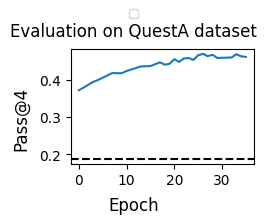

In [10]:
n_rows = 1
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.0 * n_rows), layout="constrained")

log_k = 2
map_keys = {
    int(key.split("epoch")[1]): key for key in all_results
}

x_range = sorted(map_keys.keys())
y_vals = [
    all_results[map_keys[key]][log_k] for key in x_range
]

ax = axes
ax.axhline(
    baseline_pass_k_results[log_k],
    c="black",
    linestyle="--",
)
ax.plot(
    x_range,
    y_vals,
)
# ax.set_xticks(x_range)
# ax.set_ylim(-0.1, 1.1)

fig.suptitle("Evaluation on QuestA dataset")
fig.supylabel("Pass@4")
fig.supxlabel("Epoch")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [11]:
all_results

{'local_eval-hint_rl_163-epoch0epochstep13globalstep13': array([0.16439557, 0.2602151 , 0.37244623, 0.48354021]),
 'local_eval-hint_rl_163-epoch3epochstep13globalstep55': array([0.17835942, 0.27858299, 0.39514301, 0.50782515]),
 'local_eval-hint_rl_163-epoch4epochstep13globalstep69': array([0.18604965, 0.28590702, 0.40021587, 0.51430113]),
 'local_eval-hint_rl_163-epoch7epochstep13globalstep111': array([0.19745008, 0.30209699, 0.41890371, 0.52833243]),
 'local_eval-hint_rl_163-epoch8epochstep13globalstep125': array([0.19718025, 0.30281011, 0.41844885, 0.52833243]),
 'local_eval-hint_rl_163-epoch9epochstep13globalstep139': array([0.19927145, 0.30294503, 0.41851052, 0.53157043]),
 'local_eval-hint_rl_163-epoch10epochstep13globalstep153': array([0.20534269, 0.30969085, 0.42446226, 0.53696708]),
 'local_eval-hint_rl_163-epoch13epochstep13globalstep195': array([0.21593362, 0.32281628, 0.43671267, 0.54398273]),
 'local_eval-hint_rl_163-epoch15epochstep13globalstep223': array([0.22011603, 0.3